# <h1 align="center">Assignment3</h1>

Data Link for Assignment 3 https://app.box.com/s/7qv44umhw0vnzgmoe9krfkfkv5kf2atv  

3) >The data file diabetes.csv contains data of 768 patients. In this data there are 8 attributes (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, and Age) and 1 response variable (Outcome). The response variable, Outcome, has binary value (1 indicating the outcome is diabetes and 0 means no diabetes). For this assignment purposes we will consider this data as a population. 

In [39]:
import pandas as pd
import numpy as np

Data Load

In [40]:
# import os
#
df = pd.read_csv('../data_raw/diabetes.csv')
# out_dir = '../output'
#
# # Create the directory if it doesn't exist
# if not os.path.exists(out_dir):
#     os.makedirs(out_dir)
#
# # Save a CSV to that directory
# df.to_csv(f'{out_dir}/diabetes_results.csv', index=False)

#Sanity check
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


### Problem A

1) >Set a seed (to ensure work reproducibility) and take a random sample of 25 observations and find the mean Glucose and highest Glucose values of this **sample** and compare these statistics with the population statistics of the same variable. You should use charts for this comparison.    (5 points)

part 1: take a random sample of 25 observations

In [41]:
 # Set seed and take sample
sample = df.sample(25, random_state=42)

part 2: take the mean Glucose and highest Glucose values of this **sample** and compare these statistics with the **population** statistics of the same variable

In [42]:
# From the general population
pop_mean_glc = df['Glucose'].mean()
pop_max_glc = df['Glucose'].max()

# From the sample
sample_mean_glc = sample['Glucose'].mean()
sample_max_glc = sample['Glucose'].max()

# Cleaned up Print Statements
print("--- Population Statistics ---")
print(f"Mean Glucose: {pop_mean_glc:.2f}")
print(f"Max Glucose:  {pop_max_glc}")

print("\n--- Sample Statistics (n=25) ---")
print(f"Mean Glucose: {sample_mean_glc:.2f}")
print(f"Max Glucose:  {sample_max_glc}")

--- Population Statistics ---
Mean Glucose: 120.89
Max Glucose:  199

--- Sample Statistics (n=25) ---
Mean Glucose: 116.64
Max Glucose:  183


part 3: use charts for this comparison.

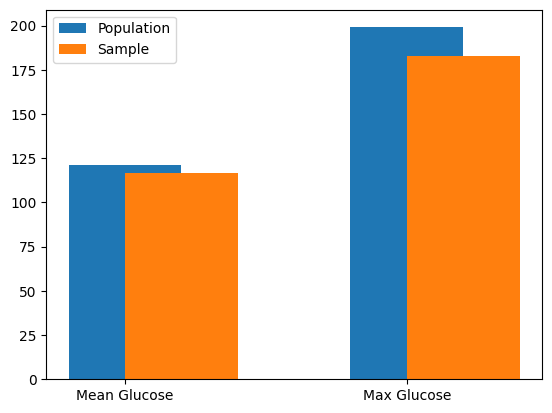

In [43]:
import matplotlib.pyplot as plt
lables = ['Mean Glucose', 'Max Glucose']
pop_vals = [pop_mean_glc, pop_max_glc]
sample_vals = [sample_mean_glc, sample_max_glc]

x = range(len(lables))
plt.bar(x, pop_vals, width=0.4, label='Population', align='center')
plt.bar(x, sample_vals, width=0.4, label='Sample', align='edge')
plt.xticks(x, lables)
plt.legend()
plt.show()

### Problem B
2) >b) Find the 98th percentile of BMI of your sample and the population and compare the results using charts. (5 points)
> - Pandas has a built in quantile function which can obtain the 98th percentile by passing it 0.98 as an argument

In [44]:
pop_98th_BMI = df['BMI'].quantile(0.98)

sample_98th_BMI = sample['BMI'].quantile(0.98)

print(f"Population 98th Percentile: {pop_98th_BMI}")
print(f"Sample 98th Percentile: {sample_98th_BMI}")

Population 98th Percentile: 47.52599999999996
Sample 98th Percentile: 40.248


Bar Chart Comparison:

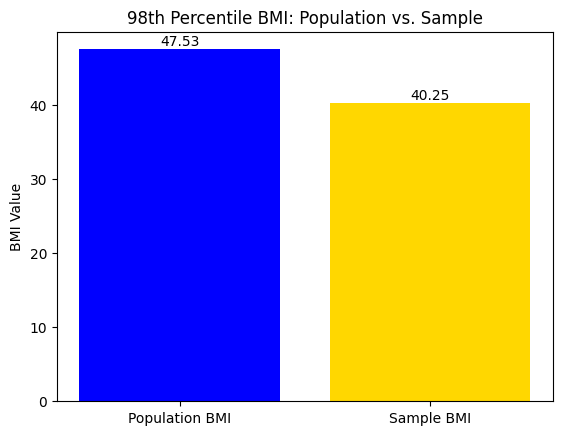

In [45]:
# Data for plotting
labels = ['Population BMI', 'Sample BMI']
values = [pop_98th_BMI, sample_98th_BMI]

# Initialize chart with lables and values
plt.bar(labels, values, color=['blue', 'gold'])
plt.ylabel('BMI Value')
plt.title('98th Percentile BMI: Population vs. Sample')

# Adding the values on top of the bars for easier analysis
for i, v in enumerate(values):
    plt.text(i, v + 0.5, f"{v:.2f}", ha='center')

plt.show()

Problem B Visual Findings:
- There is a gap between these two numbers representing > 10% difference.
- This gap illustrates sampling error and answers the question: how much can a small sample differ from the big population.
- Because the sample size is small (just25 observations) , the 98th percentile can be heavily influenced by a single outlier

### Problem C: Bootstrapping
3) >c) Using bootstrap (replace= True), create 500 samples (of 150 observation each) from the population and find the **average mean, standard deviation and percentile for BloodPressure** and compare this with these statistics from the population for the same variable. Again, you should create charts for this comparison. Report on your findings.  (10 points) 

> To do this, I will:
- 1) run a loop 500 times
- 2) Each iteration,pick 150 records at random
- 3) For each of the 500 samples, ill calculate mean, std, and 98th percentile
- 4) Finally, Ill average these 500 results and compare them to the parent global population

In [46]:
# Setup lists to store results
bootstrap_means = []
bootstrap_stds = []
bootstrap_percentiles = []

# 1. Run the Bootstrap loop
for i in range(500):
    bootstrap_sample = df['BloodPressure'].sample(150, replace=True)
    bootstrap_means.append(bootstrap_sample.mean())
    bootstrap_stds.append(bootstrap_sample.std())
    bootstrap_percentiles.append(bootstrap_sample.quantile(0.95)) # Using 95th

# 2. Calculate Population Stats
pop_mean = df['BloodPressure'].mean()
pop_std = df['BloodPressure'].std()
pop_percentile = df['BloodPressure'].quantile(0.95)

# 3. Calculate Average of Bootstrap Stats
avg_boot_mean = np.mean(bootstrap_means)
avg_boot_std = np.mean(bootstrap_stds)
avg_boot_percentile = np.mean(bootstrap_percentiles)

Visual comparison / report

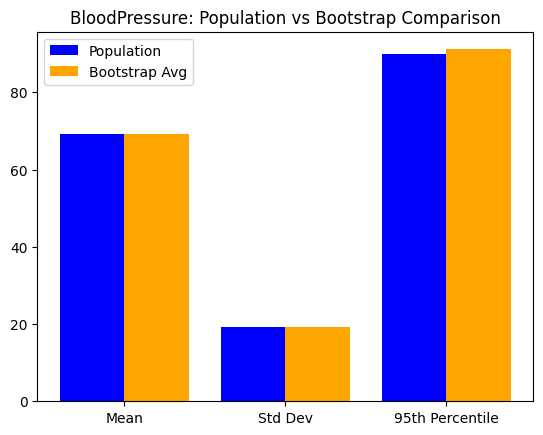

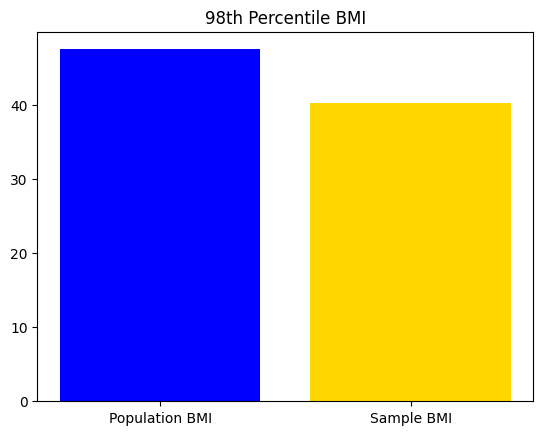

In [47]:
metrics = ['Mean', 'Std Dev', '95th Percentile']
pop_stats = [pop_mean, pop_std, pop_percentile]
boot_stats = [avg_boot_mean, avg_boot_std, avg_boot_percentile]

x = np.arange(len(metrics))
plt.bar(x - 0.2, pop_stats, 0.4, label='Population', color='blue')
plt.bar(x + 0.2, boot_stats, 0.4, label='Bootstrap Avg', color='orange')

plt.xticks(x, metrics)
plt.title('BloodPressure: Population vs Bootstrap Comparison')
plt.legend()
plt.show()

# Saving to output
plt.bar(labels, values, color=['blue', 'gold'])
plt.title('98th Percentile BMI')

# SAVE the plot to your output folder
plt.savefig('../output/bmi_comparison.png')

plt.show()

Findings / Report

Accuracy: The average bootstrap mean is very close to the population mean

Stability: Even though each of the samples are different, their collective average smooths out the noise

Spread: The STD shows more variation than the mean as it is more sensitive to the specific rows picked in the 150 samples